# Análisis Estadístico de Evaluaciones de Gramáticas

Este notebook contiene un análisis estadístico riguroso del rendimiento de distintos LLMs al usar varias gramáticas lógicas (SemGIR_APO, SemGIR, SQUALL, etc.).
A través de distintas visualizaciones y pruebas de hipótesis (T-tests), evaluamos si las diferencias de rendimiento entre gramáticas son estadísticamente significativas.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import sys
import warnings
try:
    import matplotlib_inline
    matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
except ImportError:
    pass
warnings.filterwarnings('ignore')

# Añadir el path al repositorio para poder importar utilidades si es necesario
import os
script_dir = os.path.abspath(os.getcwd())
project_root = os.path.abspath(os.path.join(script_dir, ".."))
# Remove current dir to avoid shadowing the global 'utils.py' with 'grammar_eval/utils'
sys.path = [p for p in sys.path if p != '' and os.path.abspath(p) != script_dir]
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if os.path.join(script_dir, "utils") not in sys.path:
    sys.path.append(os.path.join(script_dir, "utils"))


## 1. Carga y Procesamiento de Datos

Cargamos el archivo que contiene todas las ejecuciones individuales. En nuestra evaluación, cada consulta fue ejecutada repetidas veces por modelo para capturar la varianza introducida por la temperatura de generación del LLM. Posteriormente, agrupamos estas ejecuciones calculando su puntuación ponderada.

In [2]:
from statistical_analysis_utils import calc_run_scores

base_dir = r"../outputs/grammar_eval/combined"
df_all = pd.read_csv(f"{base_dir}\\scores_all_evaluations.csv")

grammar_mapping = {
    'semgir': 'SemGIR-APO',
    'semgir_base': 'SemGIR',
    'pccg_cgg_lambda': 'λ-Cálculo-PCCG',
    'graphq_tree': 'GraphQ',
    'lambda_dcs': 'λ-DCS',
    'nsqa': 'NSQA',
    'squall': 'SQUALL'
}
df_all['Grammar'] = df_all['Grammar'].replace(grammar_mapping)

# Calculamos la puntuación ponderada para cada ejecución individual
df_all['Weighted_Score'] = df_all['Eval Score'] * df_all['Criterion Weight']
df_all['Weighted_Supported'] = df_all['Supported_Score'] * df_all['Criterion Weight']

# Agrupamos a nivel de "Ejecución" (Run)
run_scores = df_all.groupby(['Grammar', 'Model', 'Thinking', 'Query ID', 'Run']).apply(calc_run_scores).reset_index()
run_scores.head()

# Calculamos la Mediana de las 30 ejecuciones para cada consulta
query_medians = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].median().reset_index()
query_medians.rename(columns={'Run_Overall_Score': 'Median_Overall_Score', 'Run_Supported_Score': 'Supported_Median'}, inplace=True)

# Calculamos la Media de las 30 ejecuciones para cada consulta
query_means = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].mean().reset_index()
query_means.rename(columns={'Run_Overall_Score': 'Mean_Overall_Score', 'Run_Supported_Score': 'Supported_Mean'}, inplace=True)

display(query_medians.head())


,Grammar,Model,Thinking,Query ID,Median_Overall_Score,Supported_Median
0,GraphQ,gemma4:26b,False,Q01,0.85,0.85
1,GraphQ,gemma4:26b,False,Q02,0.00,NaN
2,GraphQ,gemma4:26b,False,Q03,0.20,0.20
3,GraphQ,gemma4:26b,False,Q04,0.00,NaN
4,GraphQ,gemma4:26b,False,Q05,0.00,NaN


## 2. Visualización: Rendimiento por Gramática y Modelo (Medianas)

A continuación, representamos de forma visual el rendimiento de cada LLM en cada gramática, utilizando la **media de las medianas** obtenidas por consulta. Las barras de error sobre cada columna representan el **Intervalo de Confianza al 95%** utilizando un método paramétrico.

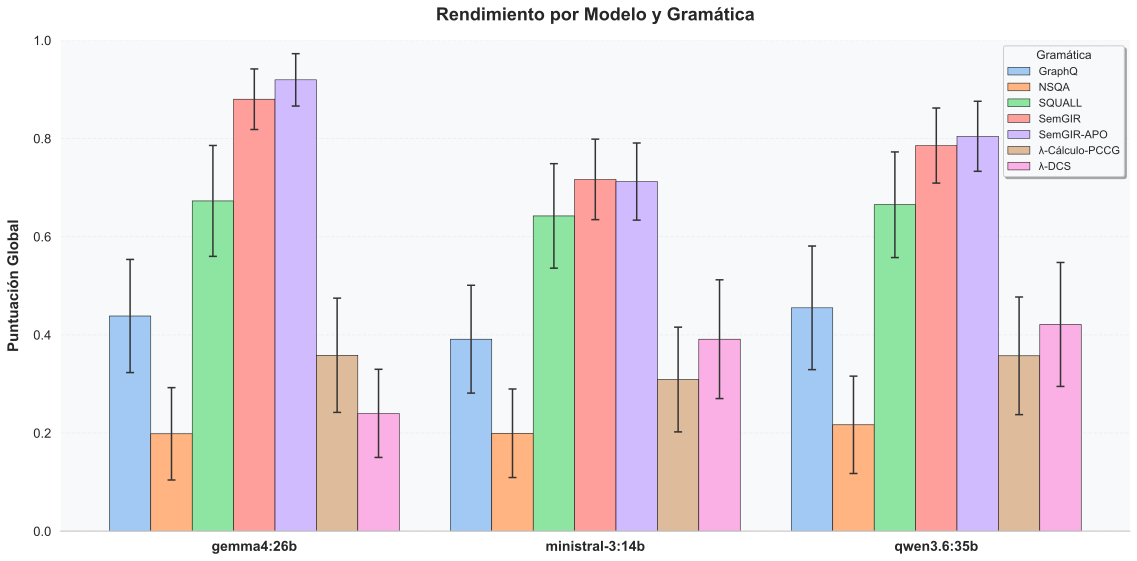

In [3]:
import numpy as np
from statistical_analysis_utils import compute_parametric_ci, plot_grouped_bars

models = query_medians['Model'].unique()
grammars = query_medians['Grammar'].unique()

means = {g: [] for g in grammars}
yerr_lower = {g: [] for g in grammars}
yerr_upper = {g: [] for g in grammars}

for m in models:
    m_data = query_medians[query_medians['Model'] == m]
    for g in grammars:
        g_data = m_data[m_data['Grammar'] == g]['Median_Overall_Score'].values
        if len(g_data) > 0:
            mean = np.mean(g_data)
            ci_low, ci_high = compute_parametric_ci(g_data)
            means[g].append(mean)
            yerr_lower[g].append(mean - ci_low)
            yerr_upper[g].append(ci_high - mean)
        else:
            means[g].append(0)
            yerr_lower[g].append(0)
            yerr_upper[g].append(0)

plot_grouped_bars(models, grammars, means, yerr_lower, yerr_upper, None, 
                  "Puntuación Global", 
                  "Rendimiento por Modelo y Gramática")


## 3. Visualización: Rendimiento por Gramática y Modelo (Medias)

Este gráfico es idéntico al anterior, pero en lugar de usar la mediana, utiliza la **media de las medias** de cada consulta. Las barras de error siguen representando el **Intervalo de Confianza al 95%**.

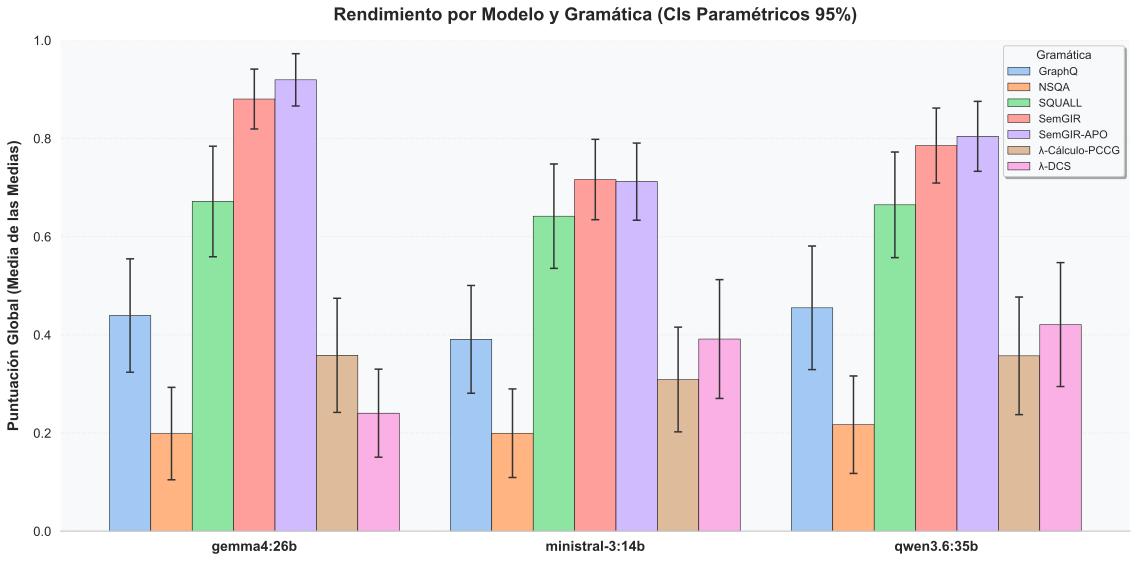

In [4]:
import numpy as np
from statistical_analysis_utils import compute_parametric_ci, plot_grouped_bars

models = query_means['Model'].unique()
grammars = query_means['Grammar'].unique()

means = {g: [] for g in grammars}
yerr_lower = {g: [] for g in grammars}
yerr_upper = {g: [] for g in grammars}

for m in models:
    m_data = query_means[query_means['Model'] == m]
    for g in grammars:
        g_data = m_data[m_data['Grammar'] == g]['Mean_Overall_Score'].values
        if len(g_data) > 0:
            mean = np.mean(g_data)
            ci_low, ci_high = compute_parametric_ci(g_data)
            means[g].append(mean)
            yerr_lower[g].append(mean - ci_low)
            yerr_upper[g].append(ci_high - mean)
        else:
            means[g].append(0)
            yerr_lower[g].append(0)
            yerr_upper[g].append(0)

plot_grouped_bars(models, grammars, means, yerr_lower, yerr_upper, None, 
                  "Puntuación Global (Media de las Medias)", 
                  "Rendimiento por Modelo y Gramática (CIs Paramétricos 95%)")


## 4. Comparación Pareada de los Mejores Lenguajes (T-Test)

A continuación se presenta una tabla por cada modelo que compara de forma pareada los lenguajes principales (**SemGIR_APO**, **SemGIR** y **SQUALL**) usando un **T-Test para muestras relacionadas (ttest_rel)** sobre la puntuación de cada consulta.
Los p-valores estadísticamente significativos (p < 0.05) se resaltan en **negrita**.

Además, se incluye la **d de Cohen** para medir el tamaño del efecto de las diferencias encontradas, cuya interpretación estándar es la siguiente:
- $|d| < 0.2$: **Insignificante**
- $0.2 \leq |d| < 0.5$: **Pequeño**
- $0.5 \leq |d| < 0.8$: **Moderado**
- $|d| \geq 0.8$: **Grande**

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import itertools
from IPython.display import display, HTML
from statistical_analysis_utils import highlight_sig

# Los 3 mejores lenguajes (representaciones) a comparar
grammars_to_compare = ['SemGIR-APO', 'SemGIR', 'SQUALL']
models_list = query_medians['Model'].unique()

# Generamos automáticamente todos los pares posibles (3 elementos -> 3 combinaciones)
pairs = list(itertools.combinations(grammars_to_compare, 2))

for m in models_list:
    print(f"\n{'='*50}")
    print(f"=== Comparación de Lenguajes para: {m} ===")
    print(f"{'='*50}")
    
    data = {}
    for g in grammars_to_compare:
        g_data = query_medians[(query_medians['Model'] == m) & (query_medians['Grammar'] == g)].copy()
        # Colapsar por Query ID para evitar duplicados debido a la columna Thinking
        g_agg = g_data.groupby('Query ID')['Median_Overall_Score'].mean()
        data[g] = g_agg
    
    comparisons = []
    
    for a, b in pairs:
        scores_a = data[a]
        scores_b = data[b]
        
        # Intersectamos los índices para alinear las consultas
        common_queries = scores_a.index.intersection(scores_b.index)
        aligned_a = scores_a.loc[common_queries].values
        aligned_b = scores_b.loc[common_queries].values
        
        
        if len(aligned_a) > 1:
            diffs = aligned_a - aligned_b
            res = stats.ttest_rel(aligned_a, aligned_b)
            t_stat, p_val = float(res[0]), float(res[1])
            cohen_d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) != 0 else 0
            
            abs_d = abs(cohen_d)
            if abs_d < 0.2:
                interpretacion = 'Insignificante'
            elif abs_d < 0.5:
                interpretacion = 'Pequeño'
            elif abs_d < 0.8:
                interpretacion = 'Moderado'
            else:
                interpretacion = 'Grande'

            comparisons.append({
                'Comparación': f"{a} vs {b}",
                'Dif. Medias': diffs.mean(),
                't-statistic': t_stat,
                'p-value': p_val,
                "Cohen's d": cohen_d,
                'Interpretación': interpretacion,
                'Significativo (p<0.05)': 'S' if p_val < 0.05 else 'No'
            })
            
    df_comp = pd.DataFrame(comparisons)
    for col in ['Dif. Medias', 't-statistic', 'p-value', "Cohen's d"]:
        if col in df_comp:
            df_comp[col] = df_comp[col].astype(float).round(4)
            
    styled_df = df_comp.style.map(highlight_sig, subset=['p-value'])\
                             .apply(lambda x: ['font-weight: bold' if v == 'S' else '' for v in x], subset=['Significativo (p<0.05)'])
    display(styled_df)



=== Comparación de Lenguajes para: gemma4:26b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,0.039400,1.198900,0.237000,0.178700,Insignificante,No
1,SemGIR-APO vs SQUALL,0.246700,4.626500,0.000000,0.689700,Moderado,S
2,SemGIR vs SQUALL,0.207200,3.787900,0.000500,0.564700,Moderado,S



=== Comparación de Lenguajes para: ministral-3:14b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,-0.004400,-0.133700,0.894300,-0.019900,Insignificante,No
1,SemGIR-APO vs SQUALL,0.070000,1.200500,0.236400,0.179000,Insignificante,No
2,SemGIR vs SQUALL,0.074400,1.121600,0.268100,0.167200,Insignificante,No



=== Comparación de Lenguajes para: qwen3.6:35b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,0.018900,0.503500,0.617100,0.075100,Insignificante,No
1,SemGIR-APO vs SQUALL,0.139400,2.215600,0.031900,0.330300,Pequeño,S
2,SemGIR vs SQUALL,0.120600,1.900000,0.064000,0.283200,Pequeño,No


## 5. Desglose Detallado por Consulta (Gemma4:26b)

A continuación se presenta una tabla con 1 fila por consulta, centrándonos en el modelo **`gemma4:26b`** y comparando el rendimiento de **todas las gramáticas**.
Para cada celda, se calculan la **Media de las ejecuciones** y su correspondiente **Intervalo de Confianza (Margen de Error)**.
El lenguaje con la puntuación más alta se muestra en **negrita**. Si la diferencia entre el mejor lenguaje y los demás **no es estadísticamente significativa** (t-test de medias independientes, $p \ge 0.05$), también se resaltan en negrita para denotar un empate estadístico.

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, HTML
from statistical_analysis_utils import compute_margin

df_gemma = run_scores[run_scores['Model'] == 'gemma4:26b'].copy()

if 'Eval Score' not in df_gemma.columns and 'Run_Overall_Score' in df_gemma.columns:
    df_gemma.rename(columns={'Run_Overall_Score': 'Eval Score'}, inplace=True)
if 'Supported_Score' not in df_gemma.columns and 'Run_Supported_Score' in df_gemma.columns:
    df_gemma.rename(columns={'Run_Supported_Score': 'Supported_Score'}, inplace=True)

queries = sorted(df_gemma['Query ID'].unique())
grammars = df_gemma['Grammar'].unique()

results = []
for q in queries:
    q_data = df_gemma[df_gemma['Query ID'] == q]
    
    q_scores = {}
    q_means = {}
    q_margins = {}
    
    for g in grammars:
        g_subset = q_data[q_data['Grammar'] == g]
        scores = g_subset['Eval Score'].dropna().values
        supported = g_subset['Supported_Score'].dropna().values
        
        if len(supported) > 0 and len(scores) > 0:
            m, h = compute_margin(scores)
            q_scores[g] = scores
            q_means[g] = m
            q_margins[g] = h
        else:
            q_scores[g] = []
            q_means[g] = -1.0
            q_margins[g] = 0.0
            
    valid_gs = [g for g in grammars if q_means[g] >= 0]
    best_g = max(valid_gs, key=lambda g: q_means[g]) if valid_gs else None
    
    row_data = {'Query ID': q}
    for g in grammars:
        m = q_means[g]
        if m < 0:
            row_data[str(g)] = "-"
            continue
            
        h = q_margins[g]
        cell_str = f"{m:.4f} &plusmn; {h*100:.1f}%"
        
        is_bold = False
        if g == best_g:
            is_bold = True
        elif best_g is not None:
            scores_best = q_scores[best_g]
            scores_curr = q_scores[g]
            
            if np.isclose(m, q_means[best_g], atol=1e-7):
                is_bold = True
            elif len(scores_best) > 1 and len(scores_curr) > 1:
                res = stats.ttest_ind(scores_best, scores_curr, equal_var=False)
                p_val = float(res[1]) # type: ignore
                if (p_val == p_val) and p_val >= 0.05:
                    is_bold = True
                elif (p_val != p_val) and np.isclose(m, q_means[best_g]):
                    is_bold = True
            elif len(scores_curr) == 0:
                is_bold = False
            else:
                if np.isclose(m, q_means[best_g]):
                    is_bold = True
                    
        if is_bold:
            row_data[str(g)] = f"<b>{cell_str}</b>"
        else:
            row_data[str(g)] = cell_str
            
    results.append(row_data)

df_queries = pd.DataFrame(results)
display(HTML(df_queries.to_html(escape=False, index=False)))


Query ID,GraphQ,NSQA,SQUALL,SemGIR,SemGIR-APO,λ-Cálculo-PCCG,λ-DCS
Q01,0.8500 ± 0.0%,1.0000 ± 0.0%,0.9833 ± 3.4%,1.0000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,0.5000 ± 0.0%
Q02,-,-,0.9983 ± 0.3%,1.0000 ± 0.0%,1.0000 ± 0.0%,0.9983 ± 0.3%,0.2467 ± 0.5%
Q03,0.2000 ± 0.0%,-,0.9500 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,-,-
Q04,-,-,-,1.0000 ± 0.0%,1.0000 ± 0.0%,-,-
Q05,-,-,0.3000 ± 0.0%,0.3033 ± 0.7%,0.3967 ± 0.7%,-,-
Q06,0.6067 ± 1.1%,0.2000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,0.5000 ± 0.0%,-
Q07,0.7500 ± 0.0%,0.4000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,0.9500 ± 0.0%,0.2200 ± 2.8%
Q08,1.0000 ± 0.0%,0.5967 ± 0.7%,1.0000 ± 0.0%,1.0000 ± 0.0%,1.0000 ± 0.0%,0.2000 ± 0.0%,0.4000 ± 0.0%
Q09,0.5000 ± 0.0%,-,-,0.5000 ± 0.0%,1.0000 ± 0.0%,-,0.0967 ± 0.5%
Q10,-,-,-,0.5167 ± 3.4%,1.0000 ± 0.0%,-,-
